# HOMEWORK 6

In this homework you are going to use the Harris corner detector to detect the corners of a document. Document detection is a crucial task for many applications, e.g., text recognition, automatic passport reading (at airport gates), etc.

You will also have to design your own feature descriptor in order to localize and distinguish among the 4 document corners.

At the end of this notebook, there are a couple of questions for you to answer.

So let's begin, shall we?

In [1]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image we will be working on in this homework.

(<Axes: >, <matplotlib.image.AxesImage at 0x1a1b6ef9610>)

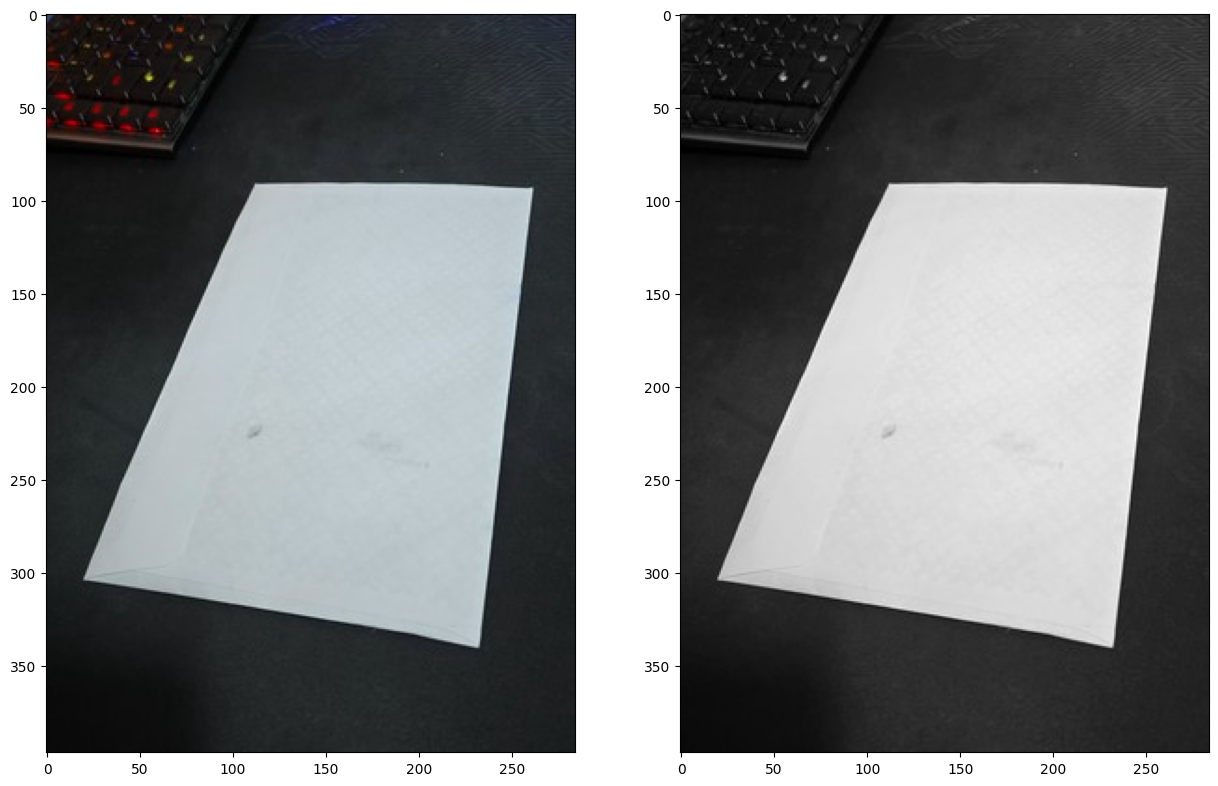

In [2]:
# Let's read the image
# img = cv2.imread('../data/document.jpg')
img = cv2.imread('../data/my.jpg')
# Convert it to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)/255.0
rows, cols = gray.shape

# Let's plot the images (colour and gray scale)
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(gray, cmap='gray')

### Harris Corner Detector
Let us now compute Harris corners. Remember that the Harris detector computes the "cornerness" score for each image pixel.

In [3]:
# Compute Harris corners (use the available OpenCV functions)
# Suggested parameters:
#            block size of 2 pixels
#            gradient kernel size of 3 pixels
#            k parameter equal to 0.04
cornerness = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# We are not interested in edges, so put to zero all negative cornerness values
cornerness[cornerness < 0] = 0.0

# Since cornerness has a huge dynamic range, let's take the logarithm for better visualization and manipulation
cornerness = np.log(cornerness + 1e-6)

(<Axes: >, <matplotlib.image.AxesImage at 0x1a1b702ac10>)

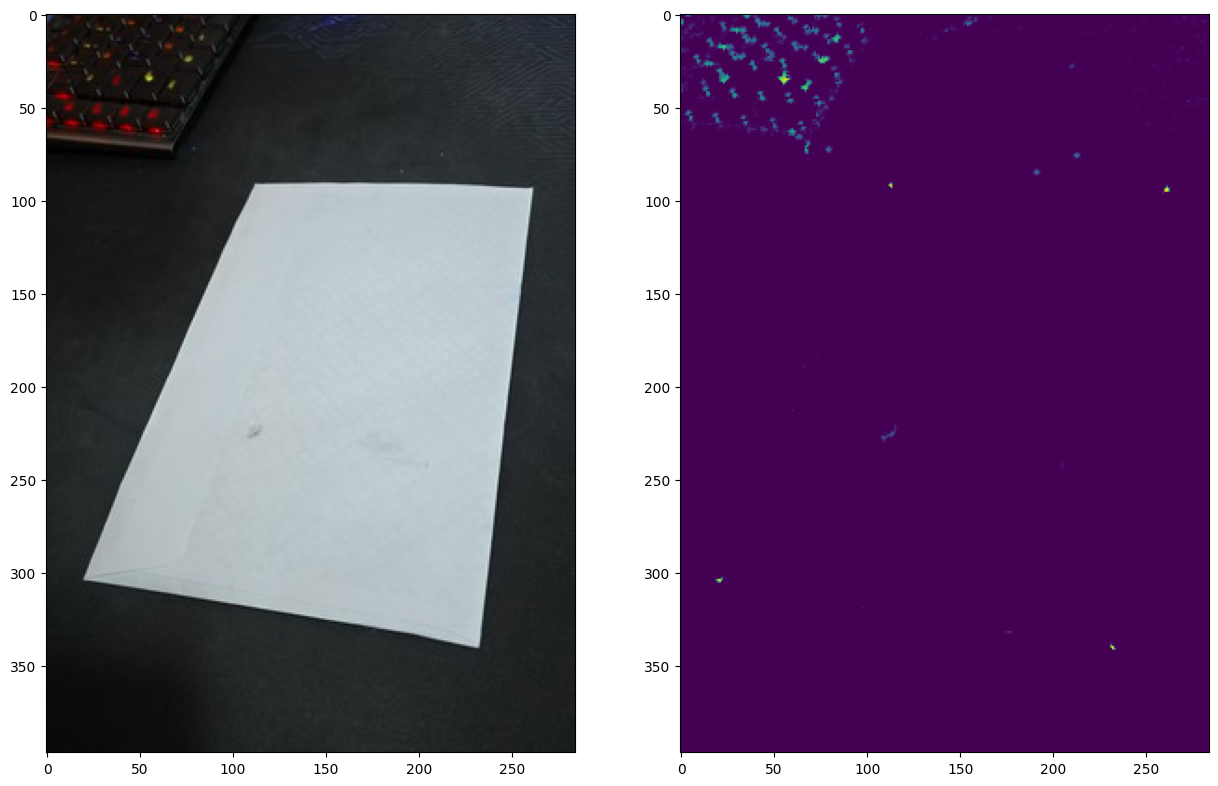

In [4]:
# Let's now plot the image and the corresponding Harris corners (in log scale)
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(cornerness)

At this point, you can see that the Harris detector has detected a lot of features. Not only the four document corners, but also the corners corresponding to (black) letters printed on (white) paper. How can we filter out everything but the 4 document corners?

For that purpose, let's design a custom feature descriptor suitable to detect the document corners. In order to do so, let's have a look at the top left corner.

![Top-left corner](../data/document_descriptor_example.jpg "Top-left corner")

A good descriptor of that corner, given a certain neghbouring region, would be to assess that the bottom-right quadrant is (much) brighter than the other three quadrants (i.e. top-left, top-right, bottom-left). Let's then implement it :-) I'll do the implementation for the top-left corner, you shall do the rest.

(<Axes: >, <matplotlib.image.AxesImage at 0x1a1b7233e50>)

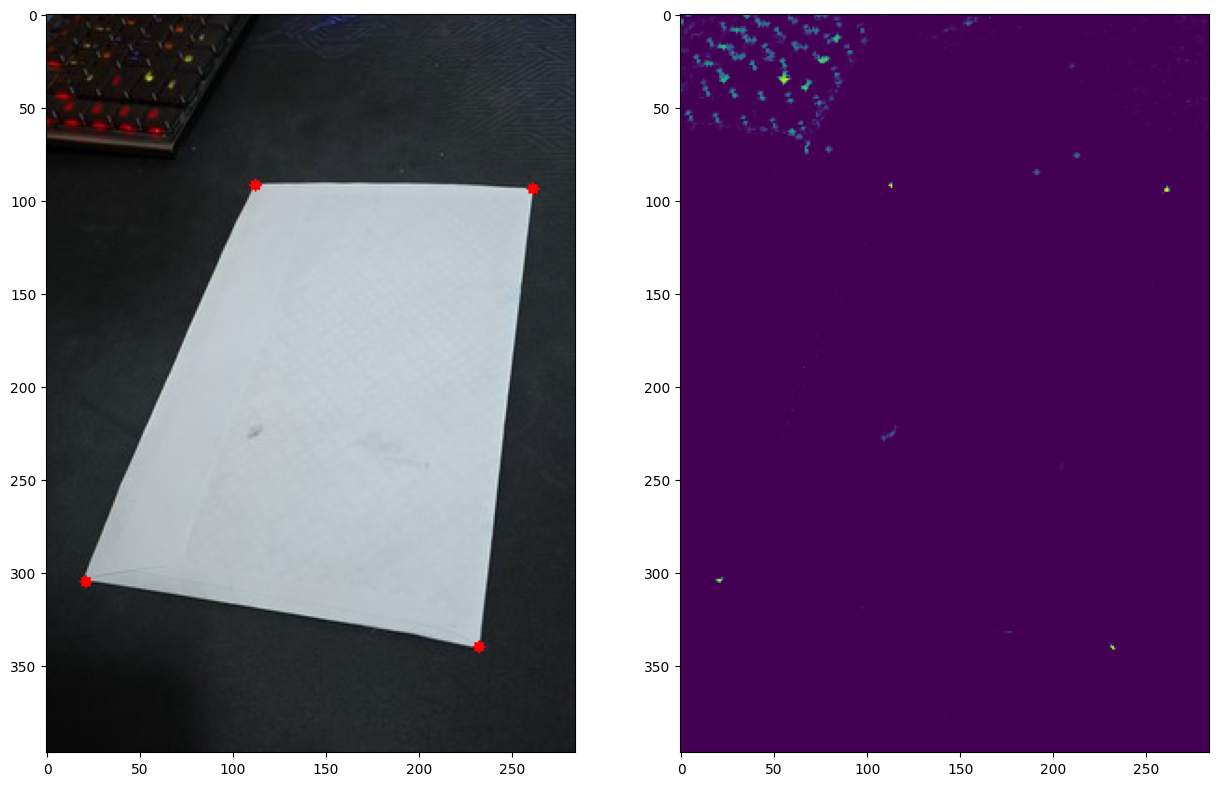

In [5]:
# Detection thresholds
ThTL, ThTR = -1e6, -1e6
ThBL, ThBR = -1e6, -1e6

# Corner coordinates
opt_TL, opt_TR = None, None
opt_BL, opt_BR = None, None

# Size of each quadrant (in pixels)
quad_size = 7

# Let's now scan the Harris detection results
for r in range(quad_size, rows-quad_size):
    for c in range(quad_size, cols-quad_size):
        # Edges with too small cornerness score are discarded, -7 seems like a good value
        if cornerness[r, c] < -7:
            continue
        
        # Extract block consisting of 4 quadrants
        block = 255*gray[r-quad_size:r+quad_size+1, c-quad_size:c+quad_size+1]
        
        # Extract the four quadrants
        QTL = block[:quad_size, :quad_size]
        QTR = block[:quad_size, quad_size + 1:]
        QBL = block[quad_size + 1:, :quad_size]
        QBR = block[quad_size + 1:, quad_size + 1:]
        
        # Top-left corner
        # For the top-left document corner, the bottom-right quadrant is mostly paper and the rest is
        # darker background. Therefore, I suggest the descriptor to be the average difference between
        # the paper quadrant and the sum of the 3 remaining background quadrants
        descriptor = np.mean(QBR) - \
                     np.mean(QTL) - np.mean(QTR) - np.mean(QBL)
        # Let's detect the best descriptor
        if descriptor > ThTL:
            # We update the threshold
            ThTL = descriptor
            # And we update the optimal location
            opt_TL = (c, r)
            
        # Top-right corner
        descriptor = np.mean(QBL) - \
                     np.mean(QTL) - np.mean(QTR) - np.mean(QBR)
        if descriptor > ThTR:
            ThTR = descriptor
            opt_TR = (c, r)
            
        # Bottom-left corner
        descriptor = np.mean(QTR) - \
                     np.mean(QTL) - np.mean(QBL) - np.mean(QBR)
        if descriptor > ThBL:
            ThBL = descriptor
            opt_BL = (c, r)
            
        # Bottom-right corner
        descriptor = np.mean(QTL) - \
                     np.mean(QTR) - np.mean(QBL) - np.mean(QBR)
        if descriptor > ThBR:
            ThBR = descriptor
            opt_BR = (c, r)

# Let's draw circles at the detected corners
out = cv2.circle(img, opt_TL, 3, (255, 0, 0), -1)
out = cv2.circle(img, opt_TR, 3, (255, 0, 0), -1)
out = cv2.circle(img, opt_BL, 3, (255, 0, 0), -1)
out = cv2.circle(img, opt_BR, 3, (255, 0, 0), -1)

# And finally we plot the images (with the detected document corners)
plt.subplot(121), plt.imshow(out)
plt.subplot(122), plt.imshow(cornerness)

### Questions
* Does it matter whether the picture has been taken by a 1Mpx camera or a 12Mpx camera? How?
* If we increased the resolution of the camera, what would you change in the current algorithm?

Remember, I am **not** looking for a particular answer. I want to see how you think, so be creative ;-)

Answer 1:
Yes, it does matter. A higher resolution camera (e.g., 12Mpx) captures more details and finer features of the document compared to a lower resolution camera (e.g., 1Mpx). This means that with a higher resolution, the Harris corner detector can identify more precise corner locations, leading to better accuracy in detecting the document corners. Additionally, higher resolution images may also help in distinguishing between the document corners and other features (like text) more effectively, as the increased pixel density provides more information for the feature descriptor to analyze.

Answer 2:
If we increased the resolution of the camera, I would consider the following changes in the current algorithm:
1. **Adjust Quadrant Size**: Since the image would have more pixels, I would increase the size of each quadrant used in the feature descriptor to ensure that it captures a sufficient area around the corners. This would help in maintaining the effectiveness of the descriptor in distinguishing between the document corners and other features.
2. **Threshold Tuning**: I would re-evaluate and potentially adjust the detection thresholds (ThTL, ThTR, ThBL, ThBR) to account for the increased pixel values and variations in brightness that may come with higher resolution images.
3. **Preprocessing**: I might implement additional preprocessing steps, such as noise reduction or contrast enhancement, to improve the quality of the image before applying the Harris corner detector, as higher resolution images can sometimes introduce more noise.